In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score , confusion_matrix , accuracy_score , roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df = pd.get_dummies(df, drop_first=True)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
num_col= df.select_dtypes(include=['int', 'float']).columns

In [6]:
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR 

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col, "outliers:", len(outliers))

Pregnancies outliers: 4
Glucose outliers: 5
BloodPressure outliers: 45
SkinThickness outliers: 1
Insulin outliers: 34
BMI outliers: 19
DiabetesPedigreeFunction outliers: 29
Age outliers: 9
Outcome outliers: 0


In [14]:
for col in num_col:
    mean = df[col].mean()
    std_dev = df[col].std()

    z_score = (df[col]-mean)/std_dev

    outlier = df[np.abs(z_score)>3]


    print(col, "Z-score outliers" , len(outlier))

Pregnancies Z-score outliers 4
Glucose Z-score outliers 5
BloodPressure Z-score outliers 35
SkinThickness Z-score outliers 1
Insulin Z-score outliers 18
BMI Z-score outliers 14
DiabetesPedigreeFunction Z-score outliers 11
Age Z-score outliers 5
Outcome Z-score outliers 0


In [7]:
X = df.drop('Outcome',axis=1)
y = df['Outcome']

In [8]:
X_train , X_test , y_train , y_test= train_test_split(X,y,test_size=0.2)

In [9]:
clf = DecisionTreeClassifier()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(y_pred)

[0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 1 0 1 0 0 0
 0 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 1 0 1 0 1 1 0 1 0 0 1 0 1 0 1 1 1 1 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0 1 0 1 0 0 1 1 0
 0 0 1 0 1 1 0 1 1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0 1 0 1 1 1 0 0 0 0 1
 1 1 0 0 0 0]


In [10]:
print("Accuracy" , accuracy_score(y_test,y_pred))

print("\nconfusion_matrix")
print(confusion_matrix(y_test,y_pred))

Accuracy 0.7272727272727273

confusion_matrix
[[79 24]
 [18 33]]


In [15]:
from sklearn import metrics


y_prob = clf.predict_proba(X_test)[:,1]
fpr,tpr,threshold = metrics.roc_curve(y_test,y_prob)
auc_score = metrics.roc_auc_score(y_test,y_prob)
print(auc_score)

0.7070245573957739


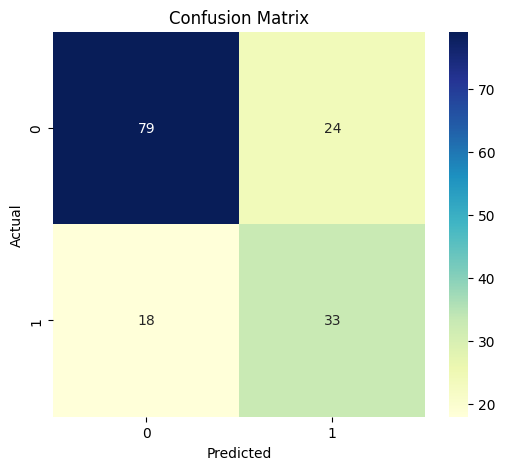

In [11]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt='g', cmap="YlGnBu")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

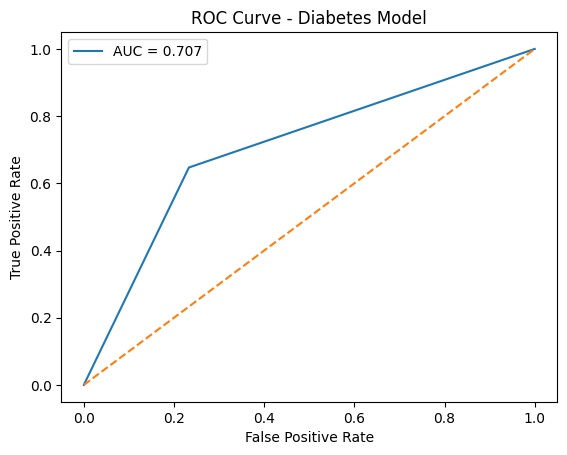

In [16]:
plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Diabetes Model")
plt.legend()

plt.show()

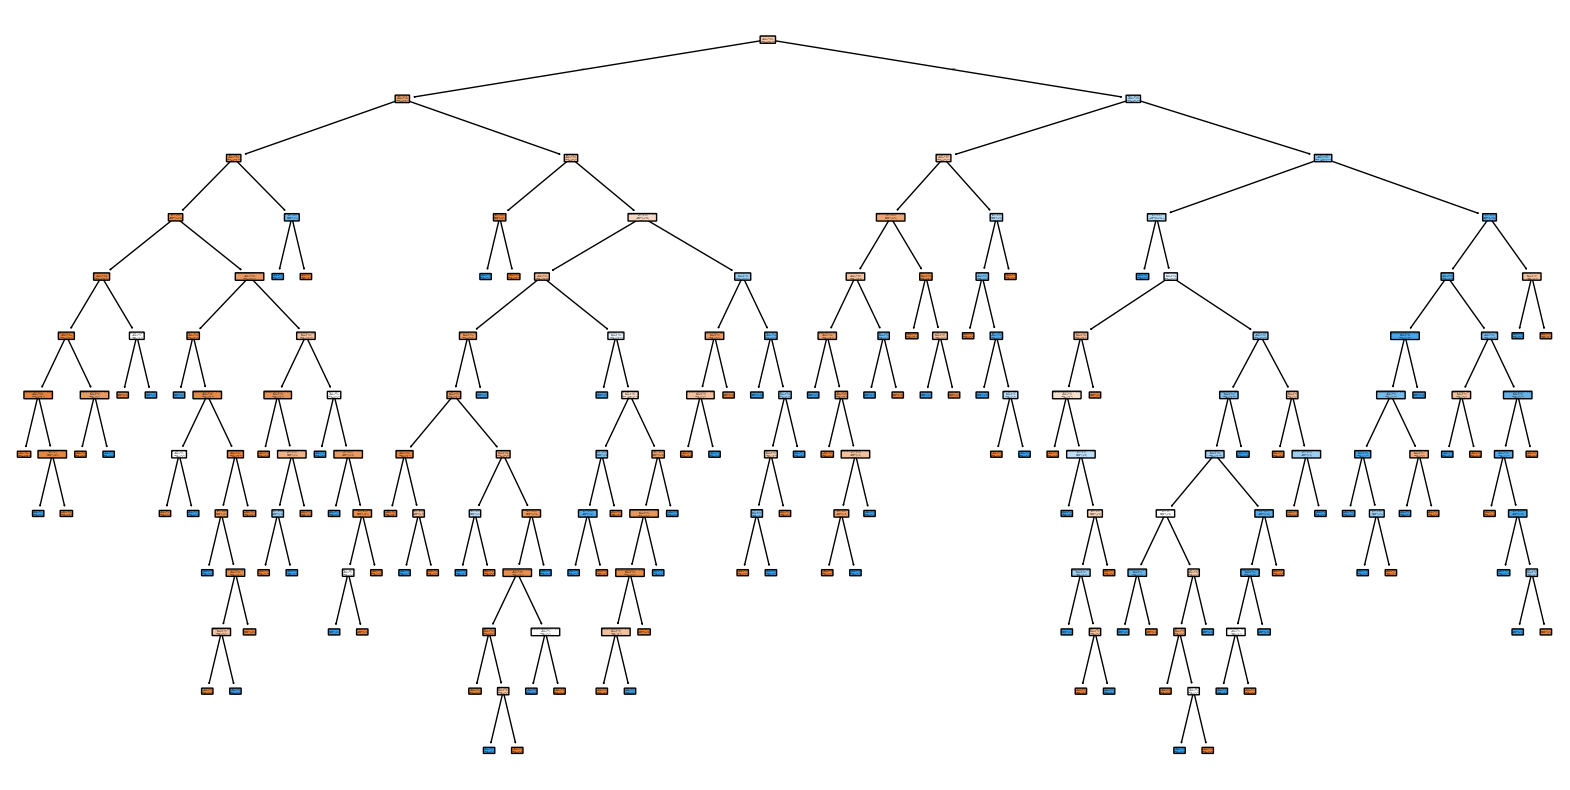

In [12]:

plt.figure(figsize=(20,10))

plot_tree(
    clf,
    feature_names=num_col,
    class_names=[str(i) for i in clf.classes_],
    filled=True,
    rounded=True
)

plt.show()

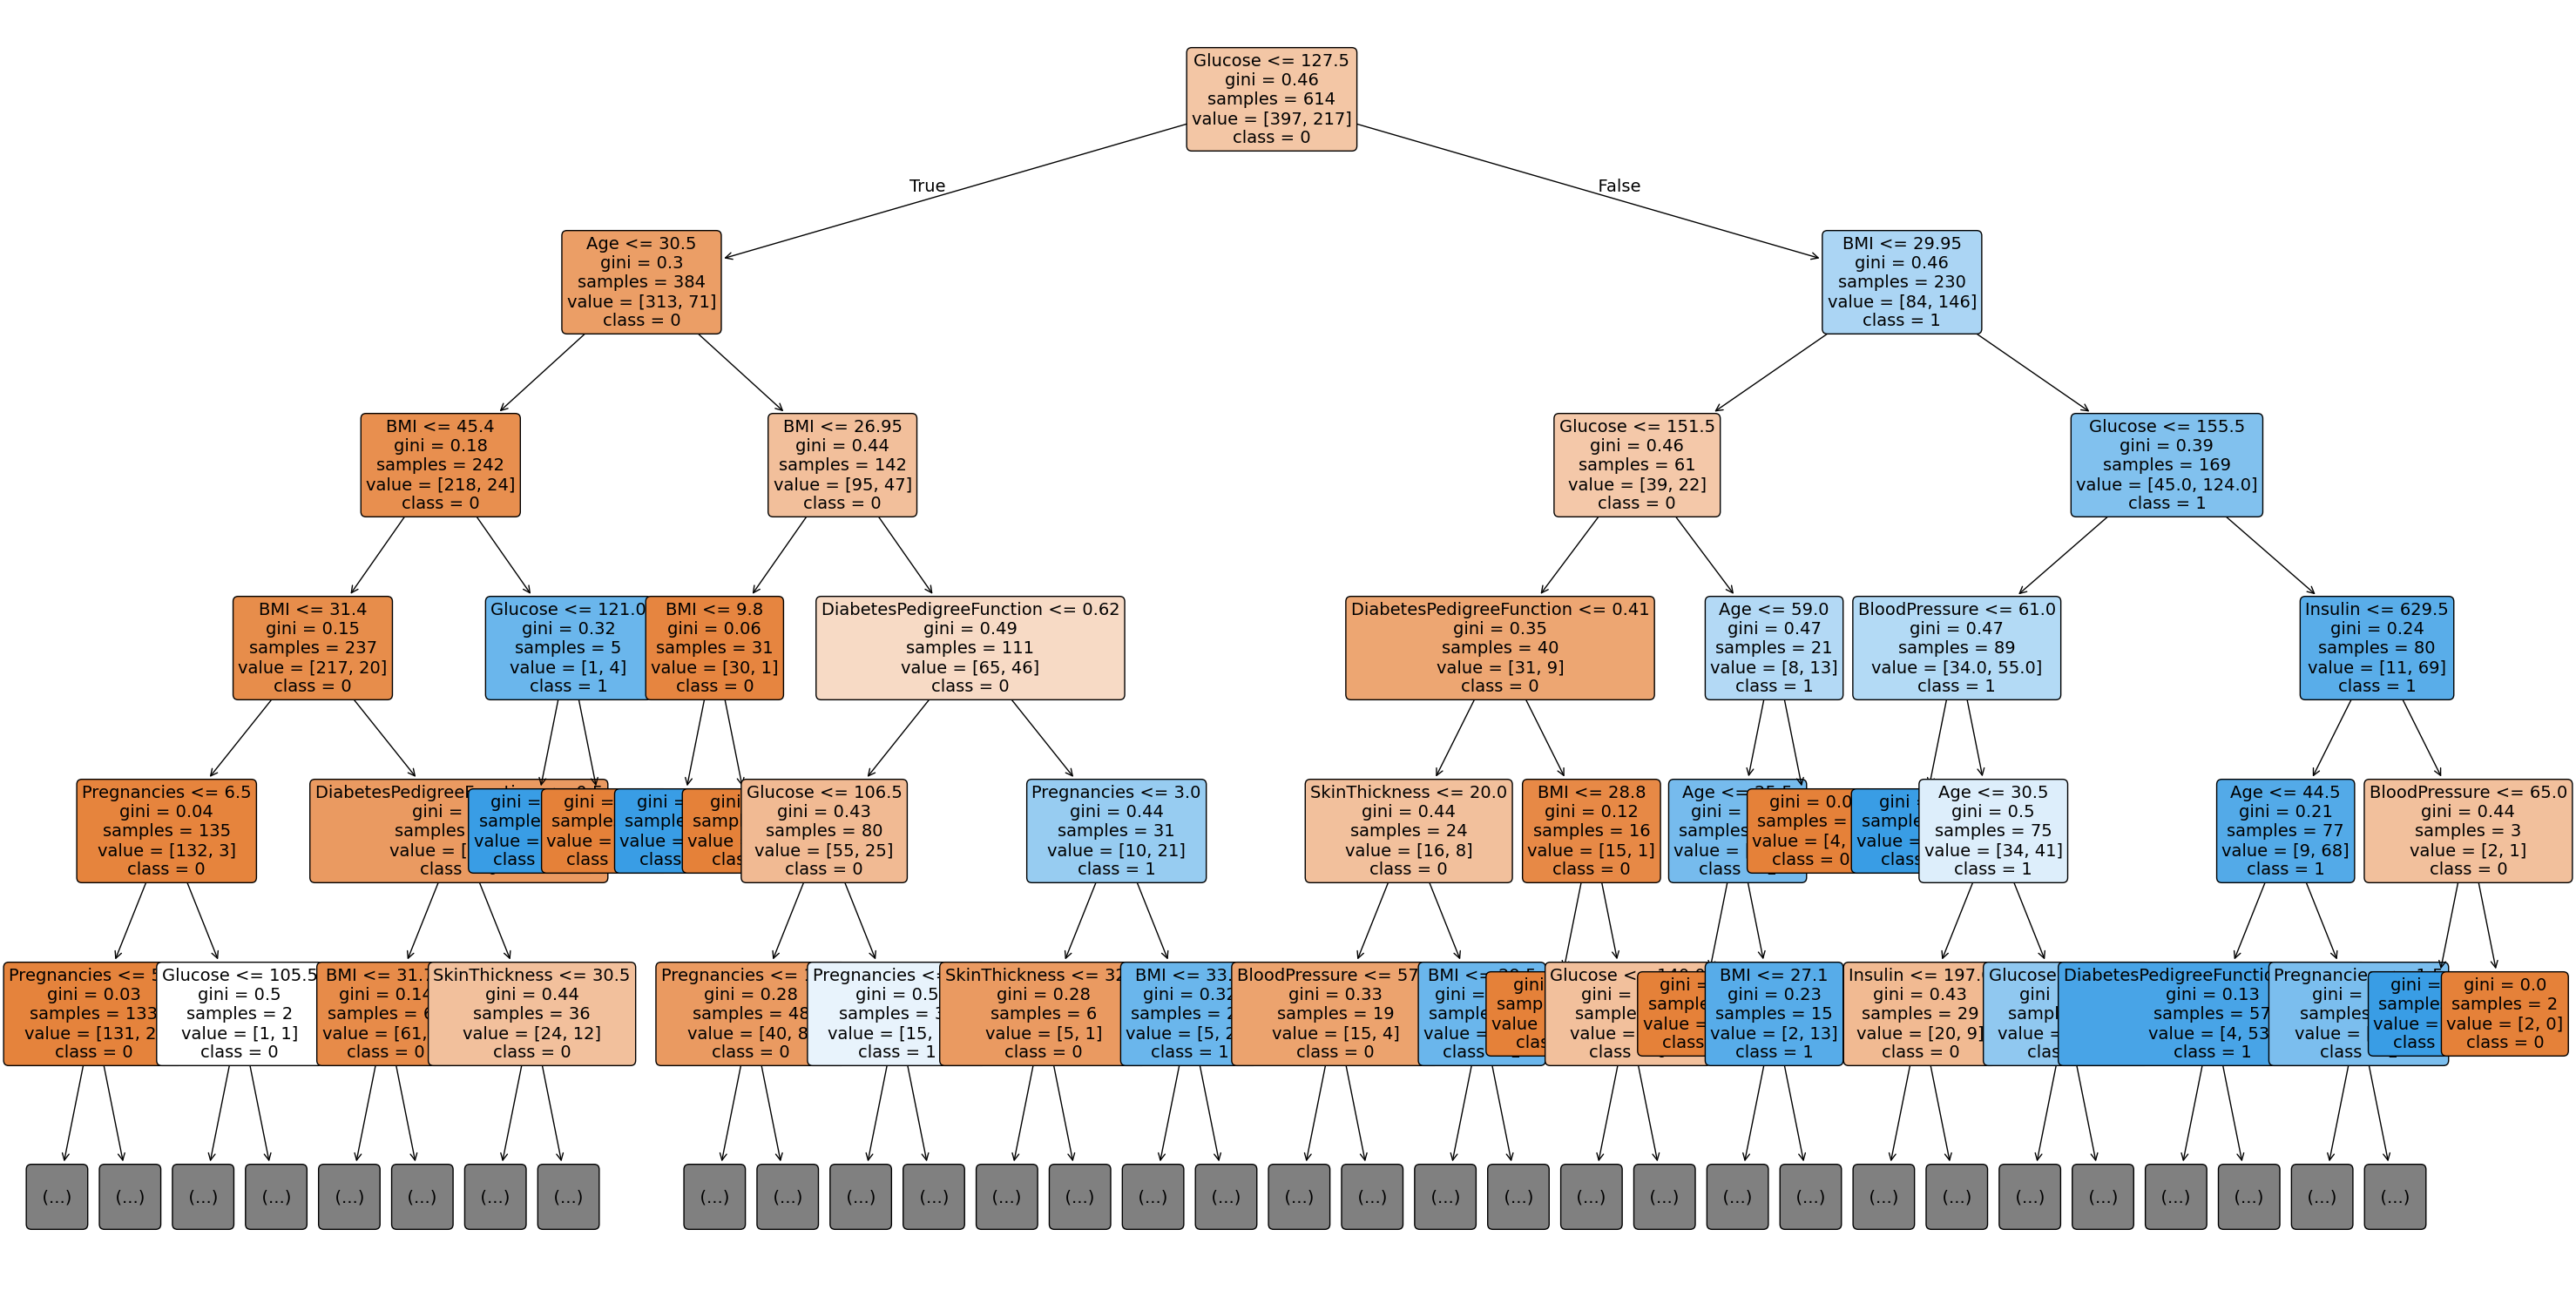

In [13]:
plt.figure(figsize=(30,15))
plot_tree(clf,
          feature_names=num_col,
          class_names=[str(i) for i in clf.classes_],
          filled=True,
          rounded=True,
          fontsize=14,
          max_depth=5,
          proportion=False,
          label='all',
          impurity=True,
          precision=2)
plt.tight_layout()
plt.show()